In [8]:

import pandas as pd
import pickle
import os
import re
def load_dict(name ):
    with open(name, 'rb') as f:
        return pickle.load(f)
def read_df():
    path = './latency/'
    for root,dirs,files in os.walk(path):
        for file in files:
            filepath = os.path.join(root,file)
            if file.endswith('res.pkl'):
                yield load_dict(filepath)
res = list(read_df())
res_df = pd.DataFrame(res)

In [14]:
latency_df = res_df[['name','qpu_width','latency_Latency']]
raw_data = pd.read_csv('./dataLatency.csv')

In [15]:
mip_latency = raw_data[['name','qpu_width','mip_Latency']]

In [16]:
latency_df


,name,qpu_width,latency_Latency
0,peexact_indep_qiskit_25,5,0.000003
1,peexact_indep_qiskit_25,16,0.000013
2,peexact_indep_qiskit_25,10,0.000008
3,graphstate_nativegates_ibm_qiskit_opt3_70,27,0.000005
4,graphstate_nativegates_ibm_qiskit_opt3_70,50,0.000005
...,...,...,...
4011,dj_indep_qiskit_116,50,0.000025
4012,e_indep_qiskit_87,50,0.000088
4013,e_indep_qiskit_87,16,0.000026
4014,e_indep_qiskit_87,27,0.000033


In [26]:
df = pd.merge(mip_latency,latency_df,on=['name','qpu_width'],how='left')

In [27]:
df


,name,qpu_width,mip_Latency,latency_Latency
0,dj_indep_qiskit_103,27,0.000013,0.000013
1,dj_indep_qiskit_103,50,0.000021,0.000025
2,dj_indep_qiskit_103,65,0.000032,0.000032
3,dj_indep_qiskit_109,27,0.000013,0.000013
4,dj_indep_qiskit_109,50,0.000021,0.000025
...,...,...,...,...
612,wstate_nativegates_ibm_qiskit_opt3_93,50,0.000000,0.000032
613,wstate_nativegates_ibm_qiskit_opt3_93,65,0.000033,0.000042
614,wstate_nativegates_ibm_qiskit_opt3_97,27,0.000017,NaN
615,wstate_nativegates_ibm_qiskit_opt3_97,50,0.000032,NaN


In [28]:
df = df[df['mip_Latency']>1e-5]

In [29]:
df

,name,qpu_width,mip_Latency,latency_Latency
0,dj_indep_qiskit_103,27,0.000013,0.000013
1,dj_indep_qiskit_103,50,0.000021,0.000025
2,dj_indep_qiskit_103,65,0.000032,0.000032
3,dj_indep_qiskit_109,27,0.000013,0.000013
4,dj_indep_qiskit_109,50,0.000021,0.000025
...,...,...,...,...
611,wstate_nativegates_ibm_qiskit_opt3_93,27,0.000017,0.000017
613,wstate_nativegates_ibm_qiskit_opt3_93,65,0.000033,0.000042
614,wstate_nativegates_ibm_qiskit_opt3_97,27,0.000017,NaN
615,wstate_nativegates_ibm_qiskit_opt3_97,50,0.000032,NaN


In [30]:
df['width'] = df['name'].apply(lambda x: int(x.split('_')[-1]))
df['name'] = df['name'].apply(lambda x:x.split('_')[0])


/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_1942/3063344466.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['width'] = df['name'].apply(lambda x: int(x.split('_')[-1]))
/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_1942/3063344466.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['name'] = df['name'].apply(lambda x:x.split('_')[0])


In [33]:
df.sort_values(by=['width'],inplace=True)

/var/folders/44/467g04mn5rl51qttrqx_q2gm0000gn/T/ipykernel_1942/2805016434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(by=['width'],inplace=True)


In [34]:
df.groupby(['name','width']).mean()

qpu_width  mip_Latency  latency_Latency
name   width                                         
dj     33     27.000000     0.000010         0.000013
       34     27.000000     0.000011         0.000013
       39     27.000000     0.000012         0.000013
       46     27.000000     0.000013         0.000013
       52     38.500000     0.000015         0.000019
...                 ...          ...              ...
wstate 108    47.333333     0.000024              NaN
       110    47.333333     0.000030              NaN
       114    47.333333     0.000024              NaN
       115    47.333333     0.000025              NaN
       124    65.000000     0.000042              NaN

[80 rows x 3 columns]

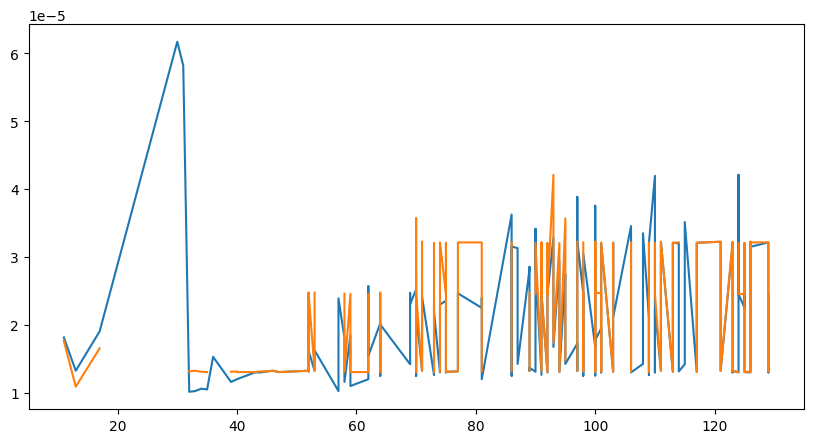

In [35]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(df['width'],df['mip_Latency'],label='MIP')
plt.plot(df['width'],df['latency_Latency'],label='Adap')

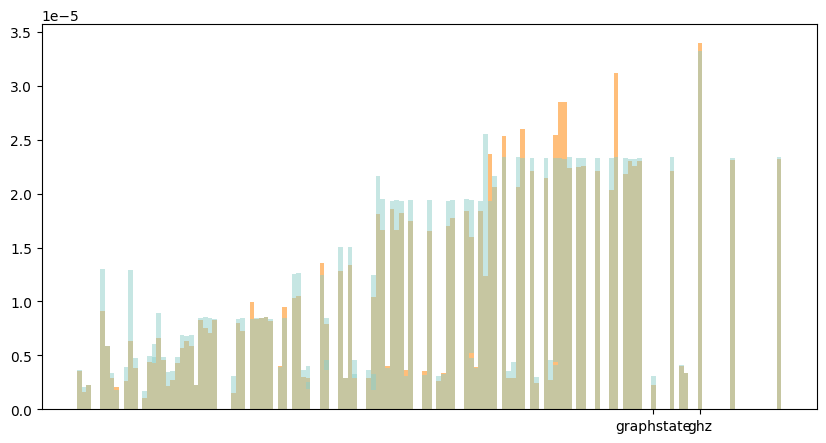

In [95]:
## 绘制柱状图比较两者latency 指标
import numpy as np
plt.figure(figsize=(10,5))
## 需要错开一点点，不然会重叠
## 用plt.barh()绘制横向柱状图
colors = ['#8ECFC9',
           "#FFBE7A",
           "#FA7F6F",
           "#82B0D2",
           "#BEB8DC",
           "#E7DAD2"]
widths = df['width'].unique()
for w in widths:
    d = df[df['width']==w]
    ## 用np.arange()生成一个等差数列，用来表示x轴上的位置
    x = np.arange(len(d))
    ## 用plt.bar()绘制柱状图
    plt.bar(x+w*0.1, d['mip_Latency'], width=0.1, label='MIP',color=colors[1])
    ## 标注name
    plt.bar(x+w*0.1, d['latency_Latency'], width=0.1, label='Adap',color=colors[0],alpha=0.5)
    plt.xticks(x+w*0.1, d['name'])